# Expectation of Continuous Random Variables

Let $X$ be a continuous random variable with probability density function $p(x)$.

The **expectation** (or **expected value**) of $X$ is defined by

$$
\boxed{
E[X]
=
\int_{-\infty}^{\infty}
x\,p(x)\,dx,
}
$$

provided that the integral converges.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.integrate import trapezoid

rng = np.random.default_rng(42)

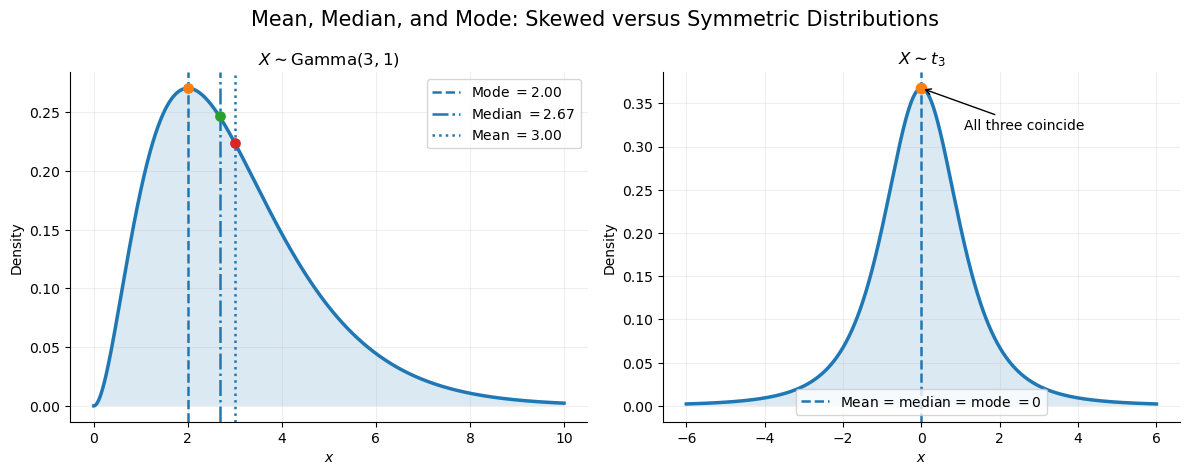

In [14]:
shape = 3
scale = 1
degrees_of_freedom = 3

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.8)
)

# ---------------------------------------------------------
# Gamma distribution
# ---------------------------------------------------------

x_gamma = np.linspace(0, 10, 1500)

gamma_density = stats.gamma.pdf(
    x_gamma,
    a=shape,
    scale=scale
)

gamma_mean = stats.gamma.mean(
    a=shape,
    scale=scale
)

gamma_median = stats.gamma.median(
    a=shape,
    scale=scale
)

gamma_mode = (shape - 1) * scale

axes[0].plot(
    x_gamma,
    gamma_density,
    linewidth=2.5
)

axes[0].fill_between(
    x_gamma,
    gamma_density,
    alpha=0.16
)

gamma_locations = [
    (gamma_mode, "Mode", "--"),
    (gamma_median, "Median", "-."),
    (gamma_mean, "Mean", ":")
]

for location, label, linestyle in gamma_locations:

    height = stats.gamma.pdf(
        location,
        a=shape,
        scale=scale
    )

    axes[0].axvline(
        location,
        linestyle=linestyle,
        linewidth=1.8,
        label=rf"{label} $={location:.2f}$"
    )

    axes[0].scatter(
        location,
        height,
        s=45,
        zorder=3
    )

axes[0].set(
    xlabel="$x$",
    ylabel="Density",
    title=r"$X\sim\mathrm{Gamma}(3,1)$"
)

axes[0].legend()

# ---------------------------------------------------------
# Student's t distribution
# ---------------------------------------------------------

x_t = np.linspace(-6, 6, 1500)

t_density = stats.t.pdf(
    x_t,
    df=degrees_of_freedom
)

t_mean = stats.t.mean(
    df=degrees_of_freedom
)

t_median = stats.t.median(
    df=degrees_of_freedom
)

t_mode = 0

axes[1].plot(
    x_t,
    t_density,
    linewidth=2.5
)

axes[1].fill_between(
    x_t,
    t_density,
    alpha=0.16
)

# Mean, median, and mode coincide at zero
central_height = stats.t.pdf(
    0,
    df=degrees_of_freedom
)

axes[1].axvline(
    0,
    linestyle="--",
    linewidth=1.8,
    label=(
        rf"Mean = median = mode $=0$"
    )
)

axes[1].scatter(
    0,
    central_height,
    s=55,
    zorder=3
)

axes[1].annotate(
    "All three coincide",
    xy=(0, central_height),
    xytext=(1.1, 0.32),
    arrowprops={
        "arrowstyle": "->",
        "linewidth": 1
    },
    fontsize=10
)

axes[1].set(
    xlabel="$x$",
    ylabel="Density",
    title=rf"$X\sim t_{{{degrees_of_freedom}}}$"
)

axes[1].legend()

# ---------------------------------------------------------
# Shared formatting
# ---------------------------------------------------------

for ax in axes:

    ax.grid(alpha=0.2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Mean, Median, and Mode: Skewed versus Symmetric Distributions",
    fontsize=15
)

fig.tight_layout()
plt.show()

## Expectation and Variance of a Random Vector

For a random vector

$$
\mathbf{X}
=
\begin{pmatrix}
X_1 \\
X_2 \\
\vdots \\
X_n
\end{pmatrix},
$$

the **expectation** is obtained by taking the expectation of each component:

$$
E[\mathbf{X}]
=
\begin{pmatrix}
E[X_1] \\
E[X_2] \\
\vdots \\
E[X_n]
\end{pmatrix}.
$$

Thus, $E[\mathbf{X}]$ is a vector representing the average location, or center of mass, of the distribution.

The variability of a random vector is described by its **covariance matrix**. For a two-dimensional random vector $(X,Y)$ the covariance matrix is

$$
\operatorname{Cov}(\mathbf{X})
=
\begin{pmatrix}
\operatorname{Var}(X) & \operatorname{Cov}(X,Y) \\
\operatorname{Cov}(X,Y) & \operatorname{Var}(Y)
\end{pmatrix}.
$$

### Visualizing the Mean and Covariance Matrix

The scatterplot represents observations from a two-dimensional random vector. The dashed and dotted ellipses summarize the information contained in the **covariance matrix** $\operatorname{Cov}(\mathbf{X})$. They are centered at the sample mean and correspond to one and two standard deviations, respectively.

The covariance ellipses illustrate three important aspects of the covariance matrix:

- The **center** of each ellipse is the mean vector.
- The **lengths of the major and minor axes** are proportional to the square roots of the eigenvalues of $\operatorname{Cov}(\mathbf{X})$, reflecting the variability in the principal directions of the data.
- The **orientation** of the ellipse is determined by the eigenvectors of $\operatorname{Cov}(\mathbf{X})$. If the variables are uncorrelated, the ellipse is aligned with the coordinate axes; otherwise, it is rotated.

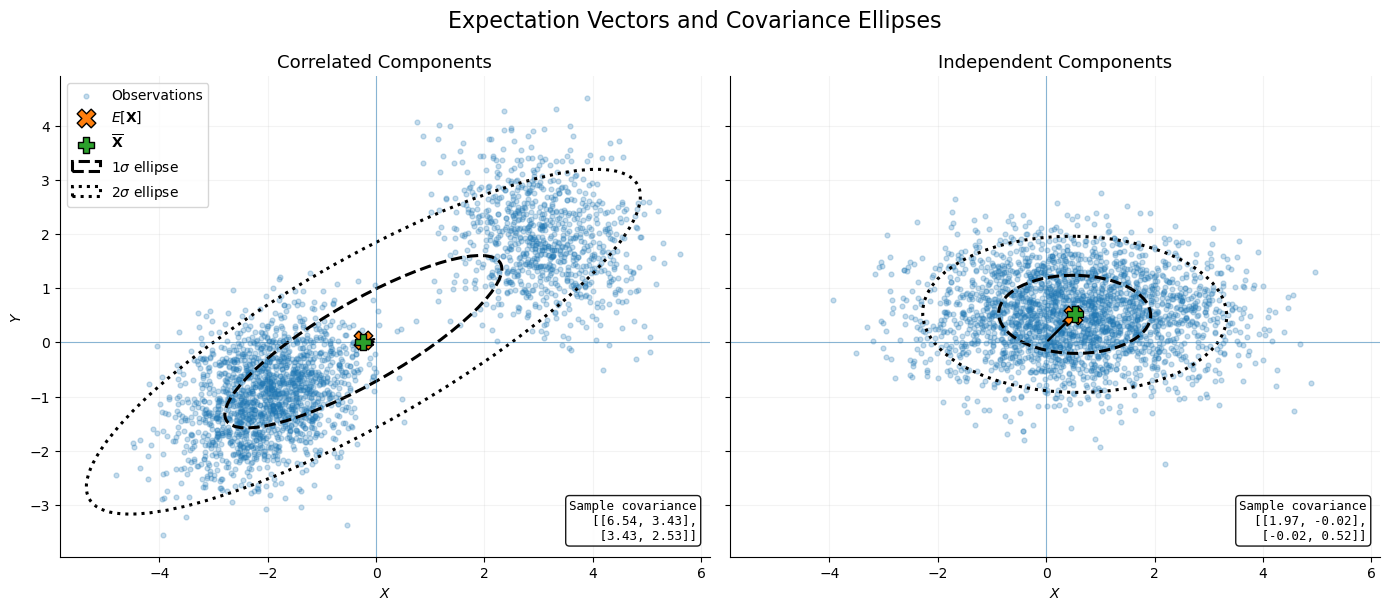

In [17]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Ellipse

rng = np.random.default_rng(42)


def add_covariance_ellipse(
    ax,
    mean,
    covariance,
    standard_deviations=1,
    **kwargs
):
    """Draw a covariance ellipse."""

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0]
        )
    )

    width = (
        2
        * standard_deviations
        * np.sqrt(eigenvalues[0])
    )

    height = (
        2
        * standard_deviations
        * np.sqrt(eigenvalues[1])
    )

    ellipse = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        **kwargs
    )

    ax.add_patch(ellipse)


# ==========================================================
# Correlated random vector (mixture)
# ==========================================================

sample_size = 2500

first_probability = 0.65
second_probability = 0.35

first_mean = np.array([-2.0, -1.0])
second_mean = np.array([3.0, 2.0])

first_covariance = np.array([
    [0.7, 0.25],
    [0.25, 0.6]
])

second_covariance = np.array([
    [0.8, -0.2],
    [-0.2, 0.7]
])

mixture_component = rng.binomial(
    n=1,
    p=second_probability,
    size=sample_size
)

first_cluster = rng.multivariate_normal(
    mean=first_mean,
    cov=first_covariance,
    size=sample_size
)

second_cluster = rng.multivariate_normal(
    mean=second_mean,
    cov=second_covariance,
    size=sample_size
)

sample = np.where(
    mixture_component[:, None] == 1,
    second_cluster,
    first_cluster
)

theoretical_mean = (
    first_probability * first_mean
    + second_probability * second_mean
)

empirical_mean = sample.mean(axis=0)

empirical_covariance = np.cov(
    sample,
    rowvar=False
)

# ==========================================================
# Independent random vector
# ==========================================================

independent_mean = np.array([0.5, 0.5])

# Different variances but zero covariance
independent_covariance = np.array([
    [2.0, 0.0],
    [0.0, 0.5]
])

independent_sample = rng.multivariate_normal(
    mean=independent_mean,
    cov=independent_covariance,
    size=sample_size
)

independent_empirical_mean = independent_sample.mean(axis=0)

independent_empirical_covariance = np.cov(
    independent_sample,
    rowvar=False
)

# ==========================================================
# Plot
# ==========================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharex=True,
    sharey=True
)

datasets = [
    {
        "sample": sample,
        "mean": theoretical_mean,
        "sample_mean": empirical_mean,
        "covariance": empirical_covariance,
        "title": "Correlated Components"
    },
    {
        "sample": independent_sample,
        "mean": independent_mean,
        "sample_mean": independent_empirical_mean,
        "covariance": independent_empirical_covariance,
        "title": "Independent Components"
    }
]

for ax, data in zip(axes, datasets):

    ax.scatter(
        data["sample"][:, 0],
        data["sample"][:, 1],
        s=12,
        alpha=0.25,
        label="Observations"
    )

    ax.scatter(
        data["mean"][0],
        data["mean"][1],
        marker="X",
        s=180,
        edgecolors="black",
        linewidths=1,
        label=r"$E[\mathbf{X}]$",
        zorder=5
    )

    ax.scatter(
        data["sample_mean"][0],
        data["sample_mean"][1],
        marker="P",
        s=130,
        edgecolors="black",
        linewidths=1,
        label=r"$\overline{\mathbf{X}}$",
        zorder=5
    )

    add_covariance_ellipse(
        ax,
        data["sample_mean"],
        data["covariance"],
        standard_deviations=1,
        linewidth=2.2,
        linestyle="--",
        label=r"$1\sigma$ ellipse"
    )

    add_covariance_ellipse(
        ax,
        data["sample_mean"],
        data["covariance"],
        standard_deviations=2,
        linewidth=2.2,
        linestyle=":",
        label=r"$2\sigma$ ellipse"
    )

    ax.annotate(
        "",
        xy=data["mean"],
        xytext=(0, 0),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=1.8
        )
    )

    covariance_text = (
        "Sample covariance\n"
        f"[[{data['covariance'][0,0]:.2f}, {data['covariance'][0,1]:.2f}],\n"
        f" [{data['covariance'][1,0]:.2f}, {data['covariance'][1,1]:.2f}]]"
    )

    ax.text(
        0.98,
        0.03,
        covariance_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        family="monospace",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.9
        )
    )

    ax.axhline(
        0,
        linewidth=0.8,
        alpha=0.5
    )

    ax.axvline(
        0,
        linewidth=0.8,
        alpha=0.5
    )

    ax.set_title(
        data["title"],
        fontsize=13
    )

    ax.set_xlabel("$X$")
    ax.grid(alpha=0.15)

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel("$Y$")
axes[0].legend(loc="upper left")

fig.suptitle(
    "Expectation Vectors and Covariance Ellipses",
    fontsize=16
)

fig.tight_layout()
plt.show()

## Example: A Distribution Without Expectation

The **standard Cauchy distribution** has density

$$
f(x)
=
\frac{1}{\pi(1+x^2)},
\qquad
-\infty<x<\infty.
$$

Its expectation is

$$
E[X]
=
\int_{-\infty}^{\infty}
\frac{x}{\pi(1+x^2)}
\,dx.
$$

However,

$$
\int_{-\infty}^{\infty}
\frac{|x|}{\pi(1+x^2)}
\,dx
=
\infty.
$$

Therefore,

$$
\boxed{
E[X]\ \text{does not exist.}
}
$$

## Expectation of a Function of a Random Variable

Let $X$ be a continuous random variable with density $p(x)$, and let $g$ be any continuous function.

Then

$$
\boxed{
E[g(X)]
=
\int_{-\infty}^{\infty}
g(x)\,p(x)\,dx.
}
$$

This formula allows us to compute expectations **without first finding the distribution of** $g(X)$.

## Expectation of a Function of a Random Vector

Let $\mathbf{X}=(X_1,\ldots,X_n)$ be a continuous random vector with joint density $p(\mathbf{x})$, and let $g$ be any continuous function.

Then

$$
\boxed{
E[g(\mathbf{X})]
=
\int_{\mathbb{R}^n}
g(\mathbf{x})\,p(\mathbf{x})\,d\mathbf{x}.
}
$$

For a two-dimensional random vector $\mathbf{X}=(X,Y)$, this becomes

$$
\boxed{
E[g(X,Y)]
=
\int_{-\infty}^{\infty}
\int_{-\infty}^{\infty}
g(x,y)\,p(x,y)\,dx\,dy.
}
$$

This formula allows us to compute expectations **without first finding the distribution of** $g(\mathbf{X})$.

## Expectations and Variances of Common Continuous Distributions

<table>
<thead>
<tr>
<th>Distribution</th>
<th>Parameters</th>
<th>$E[X]$</th>
<th>$\mathrm{Var}(X)$</th>
</tr>
</thead>

<tbody>

<tr>
<td>Uniform</td>
<td>$U(a,b)$</td>
<td>$\displaystyle\frac{a+b}{2}$</td>
<td>$\displaystyle\frac{(b-a)^2}{12}$</td>
</tr>

<tr>
<td>Exponential</td>
<td>$\operatorname{Exp}(\lambda)$</td>
<td>$\displaystyle\frac1\lambda$</td>
<td>$\displaystyle\frac1{\lambda^2}$</td>
</tr>

<tr>
<td>Gamma</td>
<td>$\Gamma(\alpha,\lambda)$ (rate)</td>
<td>$\displaystyle\frac{\alpha}{\lambda}$</td>
<td>$\displaystyle\frac{\alpha}{\lambda^2}$</td>
</tr>

<tr>
<td>Normal</td>
<td>$N(\mu,\sigma^2)$</td>
<td>$\mu$</td>
<td>$\sigma^2$</td>
</tr>

<tr>
<td>Chi-Squared</td>
<td>$\chi_n^2$</td>
<td>$n$</td>
<td>$2n$</td>
</tr>

<tr>
<td>Student's $t$</td>
<td>$t_n$</td>
<td>
$\begin{cases}
0,&n>1\\
\text{undefined},&n\le1
\end{cases}$
</td>
<td>
$\begin{cases}
\displaystyle\frac{n}{n-2},&n>2\\
\infty,&1<n\le2\\
\text{undefined},&n\le1
\end{cases}$
</td>
</tr>

<tr>
<td>Fisher's $F$</td>
<td>$F_{n,m}$</td>
<td>
$\displaystyle\frac{m}{m-2},\quad m>2$
</td>
<td>
$\displaystyle
\frac{2m^2(n+m-2)}
{n(m-2)^2(m-4)},
\quad m>4$
</td>
</tr>

</tbody>
</table>

# Moment Generating Functions

Let $X$ be a random variable. The **moment generating function** of $X$ is defined by

$$
\boxed{
M_X(t)
=
\mathbb E[e^{tX}],
}
$$

for every value of $t$ for which the expectation exists.

For a discrete random variable,

$$
M_X(t)
=
\sum_x
e^{tx}\,
\mathbb P(X=x).
$$

For a continuous random variable,

$$
M_X(t)
=
\int_{-\infty}^{\infty}
e^{tx}
f_X(x)\,dx.
$$

## Taylor Expansion

The exponential function has the Taylor expansion

$$
e^{tX}
=
\sum_{k=0}^{\infty}
\frac{(tX)^k}{k!}.
$$

Taking expectations,

$$
\begin{aligned}
M_X(t)
&=
\mathbb E[e^{tX}]\\
&=
\sum_{k=0}^{\infty}
\frac{t^k}{k!}
\mathbb E[X^k].
\end{aligned}
$$

Thus, the coefficients of the Taylor series are precisely the moments of the distribution.

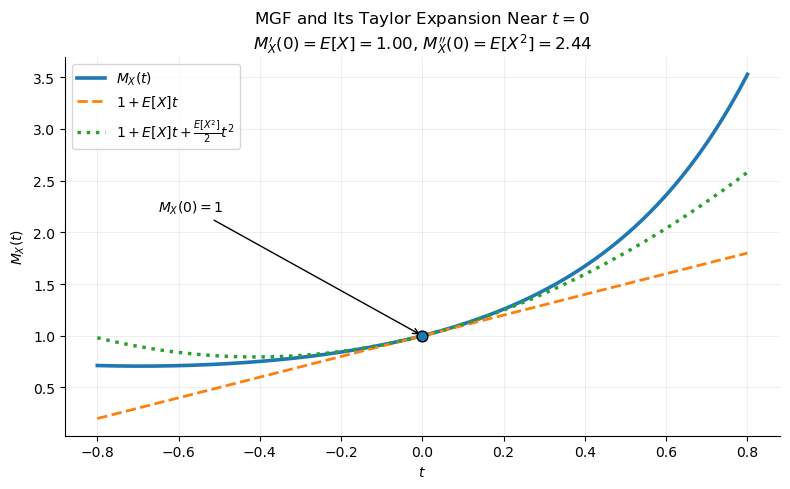

In [22]:
mu = 1
sigma = 1.2

t = np.linspace(-0.8, 0.8, 1000)

mgf = np.exp(
    mu * t
    + sigma**2 * t**2 / 2
)

first_moment = mu

second_moment = (
    mu**2 + sigma**2
)

linear_approximation = (
    1 + first_moment * t
)

quadratic_approximation = (
    1
    + first_moment * t
    + second_moment * t**2 / 2
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    t,
    mgf,
    linewidth=2.6,
    label=r"$M_X(t)$"
)

ax.plot(
    t,
    linear_approximation,
    linestyle="--",
    linewidth=2,
    label=r"$1+E[X]t$"
)

ax.plot(
    t,
    quadratic_approximation,
    linestyle=":",
    linewidth=2.5,
    label=r"$1+E[X]t+\frac{E[X^2]}{2}t^2$"
)

ax.scatter(
    0,
    1,
    s=60,
    edgecolor="black",
    linewidth=1,
    zorder=4
)

ax.annotate(
    r"$M_X(0)=1$",
    xy=(0, 1),
    xytext=(-0.65, 2.2),
    arrowprops={
        "arrowstyle": "->"
    }
)

ax.set(
    xlabel="$t$",
    ylabel="$M_X(t)$",
    title=(
        r"MGF and Its Taylor Expansion Near $t=0$"
        + "\n"
        + rf"$M_X'(0)=E[X]={first_moment:.2f}$, "
        + rf"$M_X''(0)=E[X^2]={second_moment:.2f}$"
    )
)

ax.legend()
ax.grid(alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

## Existence

Unlike expectations, moment generating functions do **not** always exist.

The expectation $\mathbb E[e^{tX}]$ must be finite.

Some heavy-tailed distributions do not possess a finite moment generating function for any nonzero value of $t$.

## Uniqueness Theorem

One of the most important theoretical results states that

> If two random variables have the same moment generating function on an open interval containing zero, then they have exactly the same probability distribution.

Therefore,

$$
M_X(t)=M_Y(t)
\quad
\Longrightarrow
\quad
X\overset{d}=Y.
$$

This theorem makes the MGF an extremely useful tool for identifying probability distributions.

## Properties

1. **Computing Moments**

   $$
   M_X^{(k)}(0)=\mathbb E[X^k],
   \qquad k=1,2,\ldots
   $$

   In particular, $\mathbb E[X]=M_X'(0)$.
   



2. **Sum of Independent Random Variables**

   If $X$ and $Y$ are independent, then

   $$
   M_{X+Y}(t)=M_X(t)M_Y(t).
   $$

   More generally, if $X_1,\ldots,X_n$ are independent, then

   $$
   M_{X_1+\cdots+X_n}(t)
   =
   \prod_{i=1}^{n} M_{X_i}(t).
   $$

## Example: Moment Generating Function of the Poisson Distribution

Let $X\sim\mathrm{Poisson}(\lambda)$, whose probability mass function is

$$
\mathbb P(X=k)
=
e^{-\lambda}
\frac{\lambda^k}{k!},
\qquad
k=0,1,2,\ldots
$$

We obain

$$
\begin{aligned}
M_X(t)
&=
\sum_{k=0}^{\infty}
e^{tk}
e^{-\lambda}
\frac{\lambda^k}{k!}\\
&=
e^{-\lambda}
\sum_{k=0}^{\infty}
\frac{(\lambda e^t)^k}{k!}\\
&=
e^{-\lambda}
e^{\lambda e^t}\\
&=
\boxed{
\exp\!\left(\lambda(e^t-1)\right).
}
\end{aligned}
$$

Notice, that all properties hold in this case. Verify it by yourself.

## Moment Generating Functions of Common Distributions

<table style="width:100%; border-collapse:collapse; text-align:center;">
<thead>
<tr>
<th>Distribution</th>
<th>Parameters</th>
<th>Moment Generating Function</th>
</tr>
</thead>

<tbody>

<tr>
<td>Bernoulli</td>
<td>$X\sim\mathrm{Bernoulli}(p)$</td>
<td>$M_X(t)=1-p+pe^t$</td>
</tr>

<tr>
<td>Binomial</td>
<td>$X\sim\mathrm{Binomial}(n,p)$</td>
<td>$M_X(t)=\left(1-p+pe^t\right)^n$</td>
</tr>

<tr>
<td>Geometric</td>
<td>$X\sim\mathrm{Geometric}(p)$</td>
<td>$M_X(t)=\dfrac{pe^t}{1-(1-p)e^t}$</td>
</tr>

<tr>
<td>Negative Binomial</td>
<td>$X\sim\mathrm{NegBin}(r,p)$</td>
<td>$M_X(t)=\left(\dfrac{pe^t}{1-(1-p)e^t}\right)^r$</td>
</tr>

<tr>
<td>Poisson</td>
<td>$X\sim\mathrm{Poisson}(\lambda)$</td>
<td>$M_X(t)=\exp\!\left(\lambda(e^t-1)\right)$</td>
</tr>

<tr>
<td>Uniform</td>
<td>$X\sim U(a,b)$</td>
<td>$M_X(t)=\dfrac{e^{tb}-e^{ta}}{t(b-a)}$</td>
</tr>

<tr>
<td>Exponential</td>
<td>$X\sim\mathrm{Exp}(\lambda)$</td>
<td>$M_X(t)=\dfrac{\lambda}{\lambda-t}$</td>
</tr>

<tr>
<td>Gamma</td>
<td>$X\sim\Gamma(\alpha,\lambda)$</td>
<td>$M_X(t)=\left(\dfrac{\lambda}{\lambda-t}\right)^\alpha$</td>
</tr>

<tr>
<td>Normal</td>
<td>$X\sim N(\mu,\sigma^2)$</td>
<td>$M_X(t)=\exp\!\left(\mu t+\dfrac{\sigma^2t^2}{2}\right)$</td>
</tr>

</tbody>
</table>

<br>

<small>

For the Geometric distribution,

$$
\mathbb P(X=k)=p(1-p)^{k-1},
\qquad
k=1,2,\ldots
$$

For the Exponential and Gamma distributions, the formulas are valid for

$$
t<\lambda.
$$

</small>

## Why Do We Care About MGFs?

At first glance, the moment generating function (MGF) may seem like just another way to describe a probability distribution. However, it is one of the most useful tools in probability theory.

First, the MGF provides a convenient way to compute the moments of a random variable. 

Even more importantly, MGFs play a central role in proving fundamental results about sums of independent random variables. In particular, they provide one of the simplest and most elegant proofs of the **Central Limit Theorem (CLT)** one of the most important results in probability and statistics.